1.	BUSINESS UNDERSTANDING
Antes de tocar ningún dato, define con precisión qué pregunta intentas responder. Un EDA sin objetivo es solo una exploración sin dirección. Escribe una problem statement en una sola frase.
-	Problem statement definida en una frase.
-	Stakeholders indentificados
-	Métricas de éxito establecidas

In [ ]:
# “Identificar los factores que influyen en la variación del precio de los alojamientos turísticos para comprender qué variables 
# explican mejor su comportamiento y detectar patrones relevantes en el mercado.”

2.	HIPÓTESIS Y PLAN DE ACCIÓN
Formula hipótesis concretas y define qué harás si se confirman o se refutan. Sin un plan de acción, los hallazgos no generan valor
-	Al menos 3 hipótesis formuladas
-	Plan de acción por cada hipótesis.

In [11]:
df.neighbourhood.value_counts()

neighbourhood
Centro                  6389
Este                     989
Carretera de Cadiz       935
Cruz De Humilladero      460
Bailen-Miraflores        312
Palma-Palmilla           217
Churriana                150
Teatinos-Universidad     100
Ciudad Jardin             88
Puerto de la Torre        41
Campanillas               33
Name: count, dtype: int64

In [ ]:
# HIPÓTESIS 1
# Los alojamientos ubicados en el Centro tienen precios más altos que los alojamientos del resto de barrios.

# JUSTIFICACIÓN DE LA HIPÓTESIS
# El Centro concentra la mayor parte de la oferta (6389 alojamientos), es la zona más turística y suele tener mayor demanda, 
# lo que razonablemente podría elevar los precios.

# PLAN DE ACCIÓN
# Si la hipótesis se confirma:
# - Analizaremos qué factores dentro del Centro explican ese precio más alto:
#       - tipo de habitación (room_type)
#       - número de reseñas (number_of_reviews)
#       - disponibilidad anual (availability_365)
#       - actividad mensual (reviews_per_month)

# Compararemos el Centro con los dos siguientes barrios más relevantes (Este y Carretera de Cádiz) para ver si la diferencia es estructural 
# o puntual.


In [ ]:
# tipo de viviendas/habitaciones
df.room_type.value_counts()

room_type
Entire home/apt    8580
Private room       1109
Shared room          21
Hotel room            4
Name: count, dtype: int64

In [ ]:
# precio medio por vivienda/habitaciones completas, no por número de personas.
df.groupby("room_type")["price"].mean()

room_type
Entire home/apt    302.61976
Hotel room         528.50000
Private room       154.28483
Shared room         48.10000
Name: price, dtype: float64

In [ ]:
# Tipo de habitaciones situadas en el "Centro"
centro = df[df["neighbourhood"] == "Centro"]
centro["room_type"].value_counts()

room_type
Entire home/apt    5813
Private room        559
Shared room          14
Hotel room            3
Name: count, dtype: int64

In [ ]:
# Precio medio por tipo de habitación situada en el "centro"
centro.groupby("room_type")["price"].mean()

room_type
Entire home/apt     229.137693
Hotel room         1000.000000
Private room         63.892632
Shared room          39.692308
Name: price, dtype: float64

In [18]:
df.groupby("host_name")["calculated_host_listings_count"].max().sort_values(ascending=False)



host_name
Jose             220
Remy             135
Living4Malaga    125
Ele              106
Pinar            101
                ... 
Ángela Y Baba      1
Ángela             1
Ángel              1
Zohair             1
Zhisen             1
Name: calculated_host_listings_count, Length: 1674, dtype: int64

In [19]:
df.groupby("host_name")["calculated_host_listings_count"].agg(["max", "count"]).sort_values("max", ascending=False)


,max,count
host_name,,
Jose,220,287
Remy,135,146
Living4Malaga,125,125
Ele,106,106
Pinar,101,101
...,...,...
Ángela Y Baba,1,1
Ángela,1,1
Ángel,1,2


In [ ]:
# cuantas personas son particulares que tienen un solo alojamiento
df[df["calculated_host_listings_count"] == 1]["host_id"].nunique()


2315

In [ ]:
# función para clasificar si se trata de particulaes o empresas 
def clasificar_host(x):
    if x == 1:
        return "Particular"
    elif x <= 5:
        return "Semi-profesional"
    elif x <= 20:
        return "Profesional"
    else:
        return "Empresa/Hotel"

df["host_type"] = df["calculated_host_listings_count"].apply(clasificar_host)


In [ ]:
df["host_type"].value_counts()

host_type
Empresa/Hotel       2964
Semi-profesional    2469
Particular          2315
Profesional         1966
Name: count, dtype: int64

In [3]:
def clasificar_disponibilidad(x):
    if x == 0:
        return "0 días"
    elif x <= 30:
        return "1-30 días"
    elif x <= 90:
        return "31-90 días"
    elif x <= 180:
        return "91-180 días"
    else:
        return "181-365 días"

df["disponibilidad_rango"] = df["availability_365"].apply(clasificar_disponibilidad)


In [ ]:
# cuantos alojamientos hay en cada rango
df["disponibilidad_rango"].value_counts().sort_index()


disponibilidad_rango
0 días           588
1-30 días        503
181-365 días    5816
31-90 días      1341
91-180 días     1466
Name: count, dtype: int64

In [ ]:
# localización de las viviendas en cada rango
df.groupby("disponibilidad_rango")["neighbourhood"].value_counts()

disponibilidad_rango  neighbourhood       
0 días                Centro                   323
                      Este                      69
                      Carretera de Cadiz        67
                      Cruz De Humilladero       52
                      Teatinos-Universidad      26
                      Bailen-Miraflores         20
                      Palma-Palmilla            12
                      Ciudad Jardin              8
                      Churriana                  8
                      Campanillas                2
                      Puerto de la Torre         1
1-30 días             Centro                   326
                      Carretera de Cadiz        68
                      Este                      46
                      Cruz De Humilladero       23
                      Churriana                 14
                      Bailen-Miraflores         10
                      Palma-Palmilla             9
                      Ciudad Jardin    

In [ ]:
# tipo de vivienda en cada rango
df.groupby("disponibilidad_rango")["room_type"].value_counts()


disponibilidad_rango  room_type      
0 días                Entire home/apt     478
                      Private room        109
                      Shared room           1
1-30 días             Entire home/apt     405
                      Private room         98
181-365 días          Entire home/apt    5262
                      Private room        531
                      Shared room          19
                      Hotel room            4
31-90 días            Entire home/apt    1129
                      Private room        211
                      Shared room           1
91-180 días           Entire home/apt    1306
                      Private room        160
Name: count, dtype: int64

In [ ]:
# ¿Influyen las malas reseñas en la disponibilidad? 
# primero vamos a calcular los tipos de reseñas
# como no tenemos un valor de esas reseñas, lo que si podemos analizar es que si influye el tener pocas reseñas en la disponibilidad
# podemos dividir los numeros de reseñas en 4 rangos para volverlo a una variable categórica


In [13]:
def clasificar_reviews(x):
    if x == 0:
        return "Sin reseñas"
    elif x <= 5:
        return "Muy pocas"
    elif x <= 20:
        return "Pocas"
    elif x <= 50:
        return "Bastantes"
    else:
        return "Muchas"


In [14]:
df["rango_reviews"] = df["number_of_reviews"].apply(clasificar_reviews)
df["rango_reviews"].value_counts()


rango_reviews
Muchas         2736
Pocas          2252
Muy pocas      1907
Bastantes      1814
Sin reseñas    1005
Name: count, dtype: int64

<Axes: xlabel='rango_reviews'>

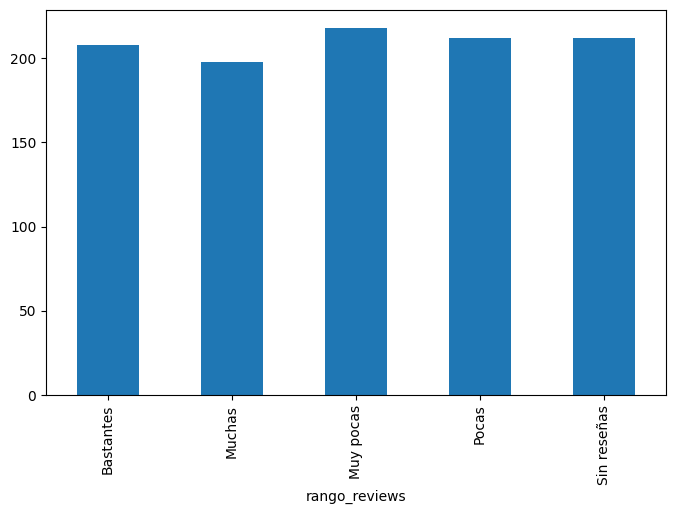

In [ ]:
# disponibilidad por rango
df.groupby("rango_reviews")["availability_365"].mean().plot(kind="bar", figsize=(8,5))


In [10]:
# Tipos de reseñas
df[["number_of_reviews", "number_of_reviews_ltm", "reviews_per_month"]].describe()



,number_of_reviews,number_of_reviews_ltm,reviews_per_month
count,9714.000000,9714.000000,8709.000000
mean,50.156578,12.758493,1.455840
std,83.001229,17.819252,1.559503
min,0.000000,0.000000,0.010000
25%,4.000000,1.000000,0.360000
50%,18.000000,5.000000,0.960000
75%,59.000000,18.000000,2.090000
max,1110.000000,211.000000,27.980000


In [ ]:
# HIPÓTESIS 2
# JUSTIFICACION DE LA HIPÓTESIS
# PLAN DE ACCIÓN

In [12]:
# HIPÓTESIS 3
# JUSTIFICACION DE LA HIPÓTESIS
# PLAN DE ACCIÓN

3.	REQUERIMIENTOS DE LOS DATOS
Identifica qué datos necesitas: granulidad, rango temporal, fuentes y variables mínimas imprescindibles para validar tus hipótesis.
-	Fuentes de datos listados
-	Granularidad y ventana temporal definidas
-	Variables mínimas necesarias identificadas.


4.	DISPONIBILIDAD
Verifica si los datos existen y si tienes acceso legar y técnico a ellos. Si no es posible, replantea el proyecto antes de invertir más tiempo.
-	Datos accesibles confimado
-	Permisos y licencias revisados


5.	ADQUISICIÓN DE LOS DATOS
Carga los datos desde su origen: CSV, base de datos, API, web scraping o dataset público.
-	Datos cargados correctamente en DataFrame
-	Backup del raw data guardado


In [2]:
import pandas as pd
df_listings = pd.read_csv("./data/listings.csv")
df = df_listings.copy()

In [7]:
df.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,96033,"Bonito piso a 200m de la playa, El Palo (Málaga)",510467,Rafael,NaN,Este,36.720310,-4.356270,Entire home/apt,58.0,3,274,2025-09-29,1.88,1,324,40,ESFCTU0000290200003588210000000000000000VUT/MA...
1,166473,Perfect Location In Malaga,793360,Fred,NaN,Este,36.720310,-4.361080,Private room,28.0,5,102,2025-03-27,0.59,5,288,3,NaN
2,330760,Malaga Lodge Guesthouse Double room-shared bath.,1687526,Mayte,NaN,Centro,36.729786,-4.413462,Private room,60.0,1,68,2025-09-04,0.41,6,64,12,ESHFTU0000290200004234200060000000000000VFT/MA...
3,340024,NEW APARTMENT IN MALAGA CENTER,1725690,Carlos,NaN,Centro,36.728130,-4.414220,Entire home/apt,61.0,3,322,2025-09-09,2.11,1,297,38,VFT/MA/02334
4,358541,Casa La Maga - Apartment for happy people,1526932,Cristina,NaN,Centro,36.723740,-4.421300,Entire home/apt,87.0,2,405,2025-07-27,2.48,1,195,23,VFT/MA/02288


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9714 entries, 0 to 9713
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              9714 non-null   int64  
 1   name                            9714 non-null   str    
 2   host_id                         9714 non-null   int64  
 3   host_name                       9714 non-null   str    
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   9714 non-null   str    
 6   latitude                        9714 non-null   float64
 7   longitude                       9714 non-null   float64
 8   room_type                       9714 non-null   str    
 9   price                           8815 non-null   float64
 10  minimum_nights                  9714 non-null   int64  
 11  number_of_reviews               9714 non-null   int64  
 12  last_review                     8709 non-null

In [10]:
df.neighbourhood.value_counts()

neighbourhood
Centro                  6389
Este                     989
Carretera de Cadiz       935
Cruz De Humilladero      460
Bailen-Miraflores        312
Palma-Palmilla           217
Churriana                150
Teatinos-Universidad     100
Ciudad Jardin             88
Puerto de la Torre        41
Campanillas               33
Name: count, dtype: int64

6.	CALIDAD DE LOS DATOS
Evalúa si los datos son suficientes, válidos y representativos. Demasiados missings o datos manipulados pueden invalidar el análisis.


In [9]:
def calidad_datos(df):
    resumen = pd.DataFrame({
        'dtype': df.dtypes,
        'nulos': df.isnull().sum(),
        'pct_nulos': (df.isnull().sum() / len(df) * 100).round(2),
        'unicos': df.nunique()
    })
    return resumen

print(calidad_datos(df))

                                  dtype  nulos  pct_nulos  unicos
id                                int64      0       0.00    9714
name                                str      0       0.00    9441
host_id                           int64      0       0.00    3504
host_name                           str      0       0.00    1674
neighbourhood_group             float64   9714     100.00       0
neighbourhood                       str      0       0.00      11
latitude                        float64      0       0.00    5559
longitude                       float64      0       0.00    6324
room_type                           str      0       0.00       4
price                           float64    899       9.25     525
minimum_nights                    int64      0       0.00      43
number_of_reviews                 int64      0       0.00     450
last_review                         str   1005      10.35     926
reviews_per_month               float64   1005      10.35     664
calculated

7.	Una vez vistos los datos reales, ajusta o reformula las hipótesis. Es normal tener que pivotarlas: los datos mandan.
-	Hipótesis revisadas contra datos disponibles
-	Variables descartadas o añadidas
